# 타이타닉 분석

# 분석 목적
# 타이타닉 생존 여부에 영향을 미친 주요 요인에 대한 제계적 분석


In [ ]:
# 1. 데이터 수집
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

from google.colab import drive
drive.mount('/content/drive')
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/titanic/train.csv')

#엑셀로 저장
df_train.to_excel("titanic.xlsx")
#df_train

![alt text](image.png)

In [ ]:
# 2. 전처리
# 2-1) 구조진단
df_train.info()

# 분석 = 인사이트
# 컬럼명을 한글로 분석완료 하였음
# 3개의 컬럼에서 결측치 보인다.
# 총 13 개의 컬럼에서 891 행의 데이터가 있다.

df_train.head(100)
# 분석 
# SibSp	Parch => 해당 데이터는 좀더 분석 필요
df_train.shape
# 분석 
# (891, 12) 13 개의 컬럼 891명의 개인 정보가 담겨져 있음



In [3]:
!pip install missingno 

Cabin          77.104377
PassengerId     0.000000
Pclass          0.000000
Survived        0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Age             0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.000000
dtype: float64


<Axes: >

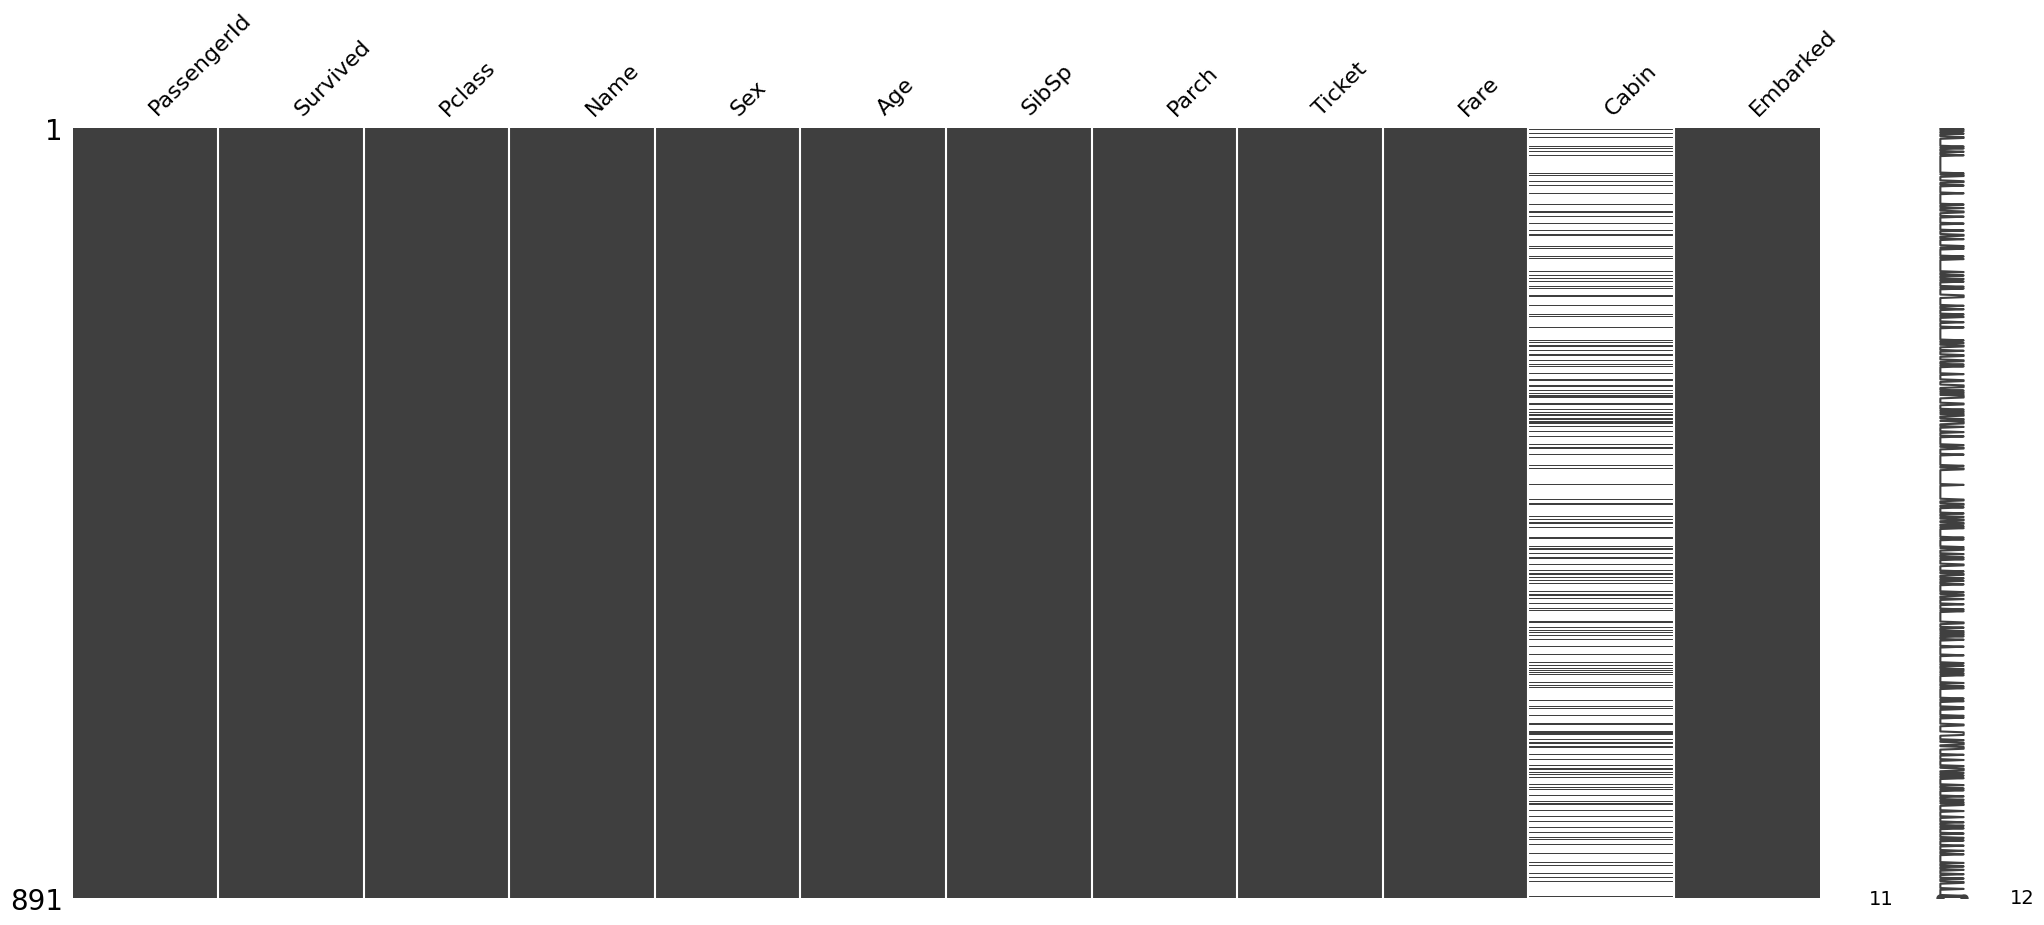

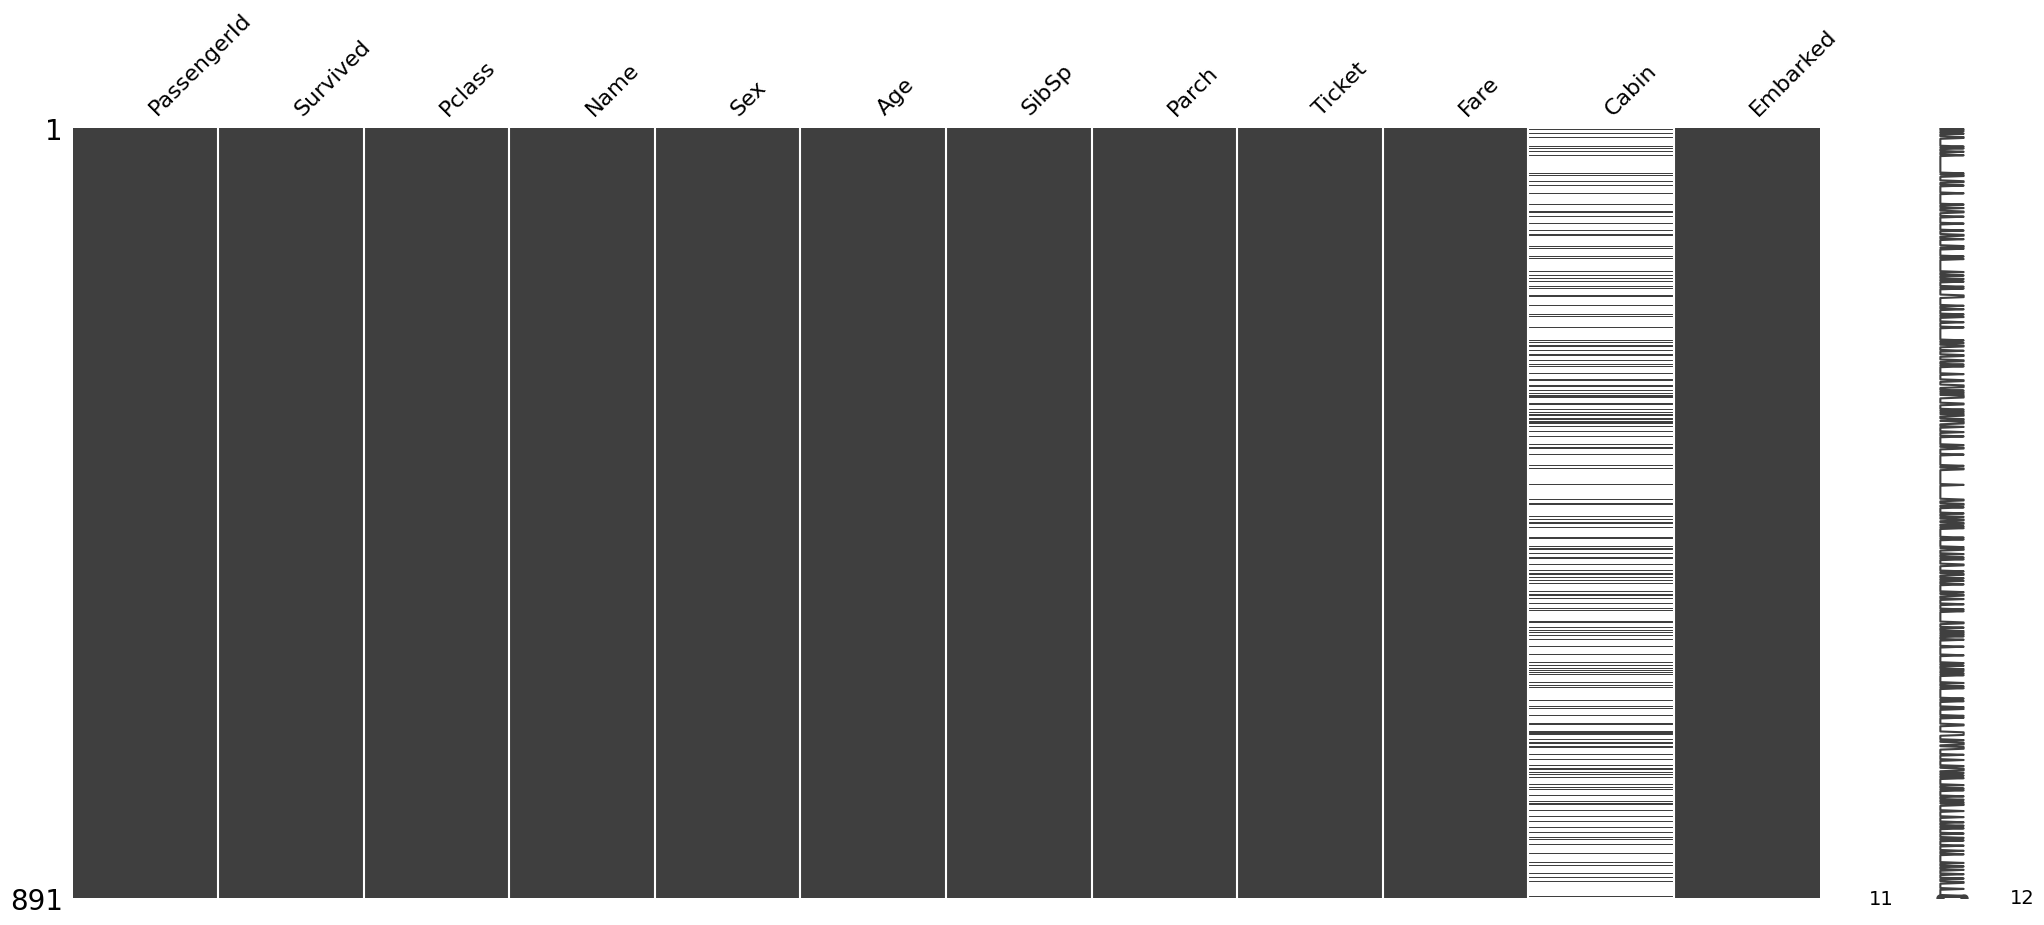

In [ ]:
import missingno as msno
# 2-2) 정제 (결측치, 이상치)
df_train.isnull().sum()
msno.matrix(df_train) 

missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
print(missing_pct)

# 1)순수 데이터 분석만 할시는 데이터 정제 및 결측치 이상치 처리할 필요 없음

# Age 결측치 처리
# 20%면 버리기 아까움. = 결측이 너무 많지는 않음
# 판단 => 채우는 방향으로 
# Age 연속형 데이타
# 숫자는 => 평균 ,중앙값, 최빈값, 최대최소 , 예측값으로 결측값을 채울수 있음
df_train["Age"].skew() #왜도 체크 값(0.38)
# 왜도 체크 => 분포가 약간 치우침
# 예시
# 0.38
# → 약한 우측 왜도 => 왜도가 있다는 말은 10, 20, 30, 40, 300 왼쪽으로 끌리는 데이터가 있다는말 임
# 평균보다 중앙값 안정.

# | 왜도 값       | 해석      |
# | ---------- | ------- |
# | -0.5 ~ 0.5 | 거의 대칭   |
# | ±0.5 ~ ±1  | 약간 치우침  |
# | ±1 이상      | 강하게 치우침 |

# | 항목   | 왜도 (Skewness)   | 첨도 (Kurtosis)       |
# | ----  | ---------------   | -------------------- |
# | 질문   | 데이터가 한쪽으로 치우쳤나? | 데이터가 뾰족하거나 꼬리가 두꺼운가? |
# | 보는 것 | 좌우 비대칭         | 중심 집중 + 꼬리 두께        |
# | 관심   | 방향                | 극단값(이상치)             |
# | 기준값  | 0                 | 0 (초과첨도 기준)          |
# | 영향   | 평균 이동           | 이상치 증가               |

df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())


# Cabin: => 77%
# 결측률이 너무큼 
# 채워도 의미 없음
# 해당행 제거시 더 큰 위험 => 데이터가 망가짐
# 제거 고려

# 결측률	판단
# < 10%	대체
# 10~30%	상황 판단
# 30~50%	신중
# >50%	제거 고려

df_train.drop(columns=["cabin"],errors="ignore",inplace=True)

# Embarked 처리
# 2 / 891 = 결측률 0.2%
# 범주형 데이터
# 최빈값으로 대체

df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])

# 전처리 판단기준
#1.결측률 체크
#2.컬럼 타입 체크
#3.데이타 분포
#4.채우면 왜곡 되는가?
#5.제거하면 손실이 큰가?

# 분석, 인사이트 발견
# Age
# → 숫자형 + 20%
# → 중앙값

# Cabin
# → 77%
# → 컬럼 제거

# Embarked
# → 범주형 + 0.2%
# → 최빈값


# 3. EDA 분석
# 4. 통계적분 분석

In [8]:
df_train["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77
